In [310]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [311]:
def read_data(path):
    df = pd.read_csv(path)
    df['id'] = df['id'].astype(str)
    df['id'] = df['id'].apply(lambda x: f'{int(x):014}' if pd.notnull(x) else x)

    return df

In [312]:
def fill_na_with_linear_reg(df):
    temp_df = df.copy()

    for col in range(len(temp_df)):
    # Get the index of NaN values in the first row
        na_index = temp_df.iloc[col].isna()[temp_df.iloc[col].isna()].index

    # Prepare the training data
        temp_train = temp_df.iloc[col].dropna()
        y = temp_train.astype(float).values.reshape(-1, 1)
        x = temp_train.index.astype(int).values.reshape(-1, 1)

    # Fit the linear regression model
        model = LinearRegression().fit(X=x, y=y)

    # Predict the NaN values
        for value in na_index:
            na = model.predict(np.array([[float(value)]]))
            temp_df.iloc[col][value] = na
    
    return temp_df

In [313]:
y_nf_formula = {'Health': [0.9, 0.1],
                'Education': [0.8, 0.2],
                'infrastructure': [0.5, 0.5],
                'environmental': [0.2, 0.8],
                'social_inclusion': [0.9, 0.1]
                }

In [314]:
y_nf_component = {'Health': ['0706', '0809'],
                'Education': ['1149', '0016'],
                'infrastructure': ['0005', '0621'],
                'environmental': ['0975', '0081'],
                'social_inclusion': ['0578', '1469']
                }

In [315]:
data = read_data('raw_clean.csv')


In [316]:
data_0706 = data[data['id'].str[0:4].str.contains(y_nf_component['Health'][0])]
data_0706_id = data_0706.set_index('id')
data_0706_clean = fill_na_with_linear_reg(data_0706_id)
data_0706_stand = data_0706_clean.copy()
for col in range(len(data_0706_stand)):
    data_0706_stand.iloc[col] = (data_0706_clean.iloc[col] - data_0706_clean.iloc[col].min()) / (data_0706_clean.iloc[col].max() - data_0706_clean.iloc[col].min())

data_0809 = data[data['id'].str[0:4].str.contains(y_nf_component['Health'][1])]
data_0809_id = data_0809.set_index('id')
data_0809_stand = fill_na_with_linear_reg(data_0809_id)
data_0809_stand = data_0809_stand.copy()
for col in range(len(data_0809_stand)):
    data_0809_stand.iloc[col] = (data_0809_stand.iloc[col] - data_0809_stand.iloc[col].min()) / (data_0809_stand.iloc[col].max() - data_0809_stand.iloc[col].min())

data_health = data_0706_stand.transpose().values * y_nf_formula['Health'][0] + y_nf_formula['Health'][1] * (1 - data_0809_stand.transpose().values)
data_health = pd.DataFrame(data_health, index=data_0706_stand.columns, columns=list(range(1, 41)))

/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_10572/1658861518.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  temp_df.iloc[col][value] = na
/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_10572/1658861518.py:19:

In [317]:
data_1149 = data[data['id'].str[0:4].str.contains(y_nf_component['Education'][0])]
data_1149_id = data_1149.set_index('id')
data_1149_clean = fill_na_with_linear_reg(data_1149_id)
data_1149_stand = data_1149_clean.copy()
for col in range(len(data_1149_stand)):
    data_1149_stand.iloc[col] = (data_1149_clean.iloc[col] - data_1149_clean.iloc[col].min()) / (data_1149_clean.iloc[col].max() - data_1149_clean.iloc[col].min())
    data_1149_stand.iloc[col] = data_1149_stand.iloc[col].fillna(1)

data_0016 = data[data['id'].str[0:4].str.contains(y_nf_component['Education'][1])]
data_0016_id = data_0016.set_index('id')
data_0016_stand = fill_na_with_linear_reg(data_0016_id)
data_0016_stand = data_0016_stand.copy()
for col in range(len(data_0016_stand)):
    data_0016_stand.iloc[col] = (data_0016_stand.iloc[col] - data_0016_stand.iloc[col].min()) / (data_0016_stand.iloc[col].max() - data_0016_stand.iloc[col].min())

data_Education = data_1149_stand.transpose().values * y_nf_formula['Education'][0] + y_nf_formula['Education'][1] * (data_0016_stand.transpose().values)
data_Education = pd.DataFrame(data_Education, index=data_1149_stand.columns, columns=list(range(1, 41)))

/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_10572/1658861518.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  temp_df.iloc[col][value] = na
/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_10572/1658861518.py:19:

In [318]:
data_0005 = data[data['id'].str[0:4].str.contains(y_nf_component['infrastructure'][0])]
data_0005_id = data_0005.set_index('id')
data_0005_clean = fill_na_with_linear_reg(data_0005_id)
data_0005_stand = data_0005_clean.copy()
for col in range(len(data_0005_stand)):
    data_0005_stand.iloc[col] = (data_0005_clean.iloc[col] - data_0005_clean.iloc[col].min()) / (data_0005_clean.iloc[col].max() - data_0005_clean.iloc[col].min())
    data_0005_stand.iloc[col] = data_0005_stand.iloc[col].fillna(1)

data_0621 = data[data['id'].str[0:4].str.contains(y_nf_component['infrastructure'][1])]
data_0621_id = data_0621.set_index('id')
data_0621_stand = fill_na_with_linear_reg(data_0621_id)
data_0621_stand = data_0621_stand.copy()
for col in range(len(data_0621_stand)):
    data_0621_stand.iloc[col] = (data_0621_stand.iloc[col] - data_0621_stand.iloc[col].min()) / (data_0621_stand.iloc[col].max() - data_0621_stand.iloc[col].min())

data_infrastructure = data_0005_stand.transpose().values * y_nf_formula['infrastructure'][0] + y_nf_formula['infrastructure'][1] * (data_0621_stand.transpose().values)
data_infrastructure = pd.DataFrame(data_infrastructure, index=data_0005_stand.columns, columns=list(range(1, 41)))

/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_10572/1658861518.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  temp_df.iloc[col][value] = na
/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_10572/1658861518.py:19:

In [319]:
data_0975 = data[data['id'].str[0:4].str.contains(y_nf_component['environmental'][0])]
data_0975_id = data_0975.set_index('id')
data_0975_clean = fill_na_with_linear_reg(data_0975_id)
data_0975_stand = data_0975_clean.copy()
for col in range(len(data_0975_stand)):
    data_0975_stand.iloc[col] = (data_0975_clean.iloc[col] - data_0975_clean.iloc[col].min()) / (data_0975_clean.iloc[col].max() - data_0975_clean.iloc[col].min())
    data_0975_stand.iloc[col] = data_0975_stand.iloc[col].fillna(1)

data_0081 = data[data['id'].str[0:4].str.contains(y_nf_component['environmental'][1])]
data_0081_id = data_0081.set_index('id')
data_0081_stand = fill_na_with_linear_reg(data_0081_id)
data_0081_stand = data_0081_stand.copy()
for col in range(len(data_0081_stand)):
    data_0081_stand.iloc[col] = (data_0081_stand.iloc[col] - data_0081_stand.iloc[col].min()) / (data_0081_stand.iloc[col].max() - data_0081_stand.iloc[col].min())
    data_0081_stand.iloc[col] = data_0081_stand.iloc[col].fillna(1)

data_environmental = (1 - data_0975_stand.transpose().values) * y_nf_formula['environmental'][0] + y_nf_formula['environmental'][1] * (data_0081_stand.transpose().values)
data_environmental = pd.DataFrame(data_environmental, index=data_0975_stand.columns, columns=list(range(1, 41)))

/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_10572/1658861518.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  temp_df.iloc[col][value] = na
/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_10572/1658861518.py:19:

In [320]:
data_0578 = data[data['id'].str[0:4].str.contains(y_nf_component['social_inclusion'][0])]
data_0578_id = data_0578.set_index('id')
data_0578_clean = fill_na_with_linear_reg(data_0578_id)
data_0578_stand = data_0578_clean.copy()
for col in range(len(data_0578_stand)):
    data_0578_stand.iloc[col] = (data_0578_clean.iloc[col] - data_0578_clean.iloc[col].min()) / (data_0578_clean.iloc[col].max() - data_0578_clean.iloc[col].min())

data_1469 = data[data['id'].str[0:4].str.contains(y_nf_component['social_inclusion'][1])]
data_1469_id = data_1469.set_index('id')
data_1469_stand = fill_na_with_linear_reg(data_1469_id)
data_1469_stand = data_1469_stand.copy()
for col in range(len(data_1469_stand)):
    data_1469_stand.iloc[col] = (data_1469_stand.iloc[col] - data_1469_stand.iloc[col].min()) / (data_1469_stand.iloc[col].max() - data_1469_stand.iloc[col].min())

data_social_inclusion = (1 - data_0578_stand.transpose().values) * y_nf_formula['social_inclusion'][0] + y_nf_formula['social_inclusion'][1] * (data_1469_stand.transpose().values)
data_social_inclusion = pd.DataFrame(data_social_inclusion, index=data_0578_stand.columns, columns=list(range(1, 41)))

/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_10572/1658861518.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  temp_df.iloc[col][value] = na
/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_10572/1658861518.py:19:

In [321]:
country_name = pd.read_csv('Country Name.csv')

In [322]:
qol_country = data_health.values * 0.3 + data_Education.values * 0.3 + data_infrastructure.values * 0.2 + data_environmental.values * 0.1 + data_social_inclusion.values * 0.1

qol_country = pd.DataFrame(qol_country, index=data_health.index, columns=country_name['Country Name'])

In [323]:
gdp_id = '470'
gdp = data[data['id'].str[0:4].str.contains(gdp_id)]
gdp_id = gdp.set_index('id')
gdp_clean = fill_na_with_linear_reg(gdp_id)
gdp_stand = gdp_clean.copy()
for col in range(len(gdp_stand)):
    gdp_stand.iloc[col] = (gdp_stand.iloc[col] - gdp_stand.iloc[col].min()) / (gdp_stand.iloc[col].max() - gdp_stand.iloc[col].min())

/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_10572/1658861518.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  temp_df.iloc[col][value] = na
/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_10572/1658861518.py:19:

In [324]:
prosperity_country = pd.DataFrame(columns=country_name['Country Name'])
for i in range(40):
    temp_df = pd.DataFrame(
        {
            'GDP': gdp_stand.transpose().iloc[:, i],
            'QOL': qol_country.iloc[:, i]
        }
    )
    pca = PCA(n_components=1)  # Only the first component for composite index
    pca.fit(temp_df)
    pc1_loadings = pca.components_[0]
    abs_loadings = np.abs(pc1_loadings)
    weights = abs_loadings / np.sum(abs_loadings)
    prosperity_country.iloc[:, i] = gdp_stand.transpose().iloc[:, i] * weights[0] + qol_country.iloc[:, i] * weights[1]

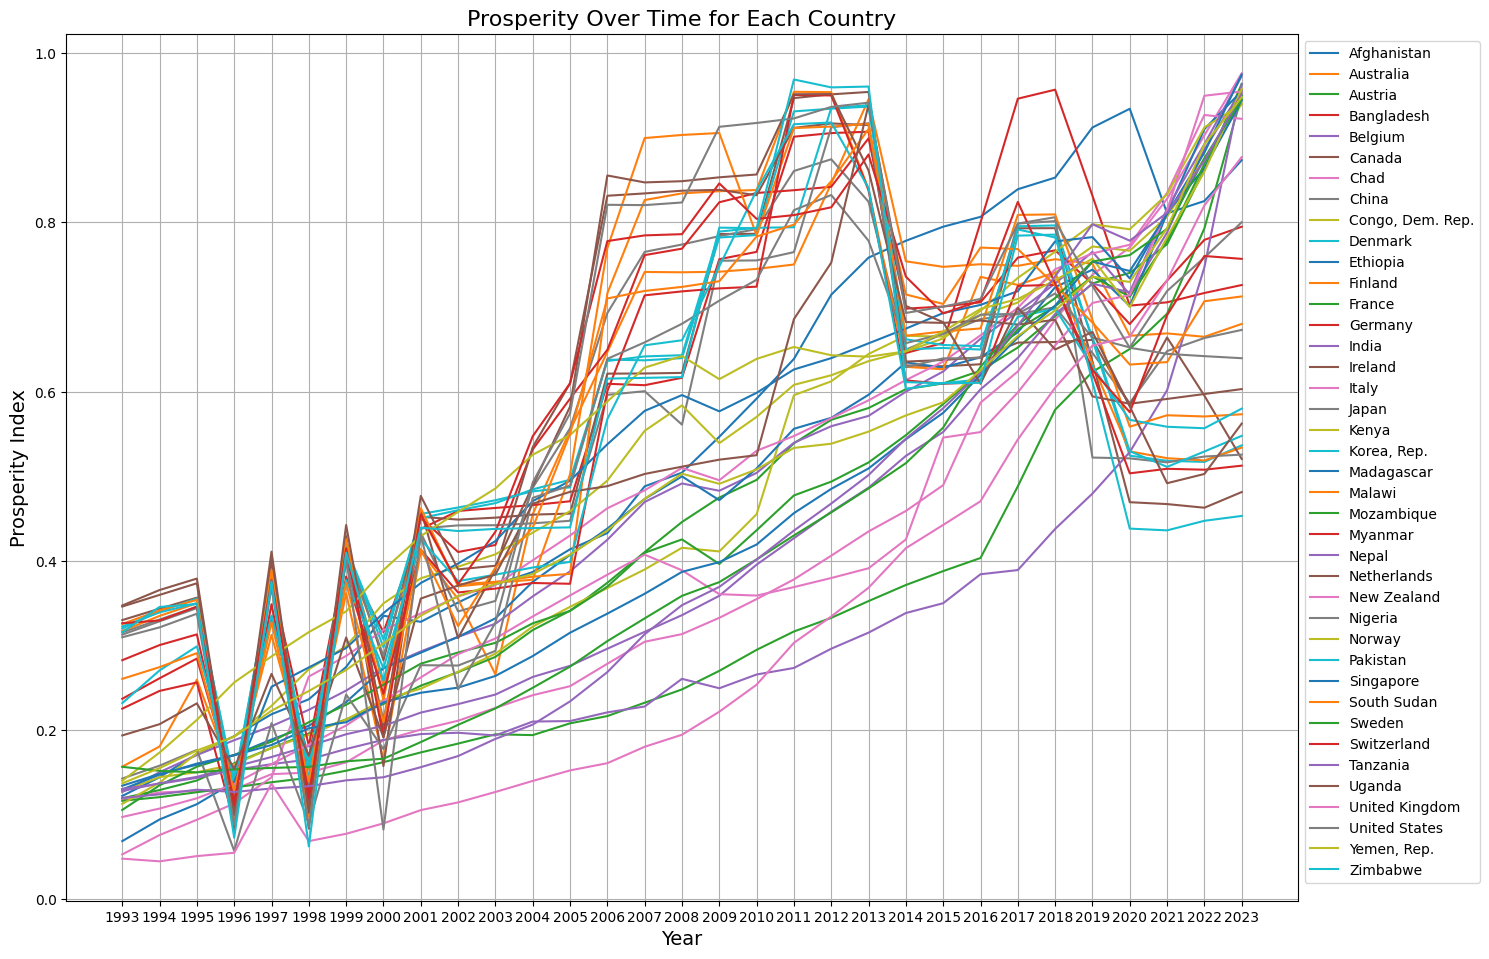

In [327]:
# Plot each country's prosperity over time
plt.figure(figsize=(15, 10))
for country in prosperity_country.columns:
    plt.plot(prosperity_country.index, prosperity_country[country], label=country)

plt.title('Prosperity Over Time for Each Country', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Prosperity Index', fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

In [325]:
combine_country = pd.read_excel('combine_country_data.xlsx')

In [326]:
combine_country

,"Adolescent fertility rate (births per 1,000 women ages 15-19)",Age dependency ratio (% of working-age population),"Age dependency ratio, old (% of working-age population)","Age dependency ratio, young (% of working-age population)",Aquaculture production (metric tons),"Birth rate, crude (per 1,000 people)",Capture fisheries production (metric tons),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)","Contributing family workers, total (% of total employment) (modeled ILO estimate)",...,Urban population growth (annual %),"Vulnerable employment, female (% of female employment) (modeled ILO estimate)","Vulnerable employment, male (% of male employment) (modeled ILO estimate)","Vulnerable employment, total (% of total employment) (modeled ILO estimate)","Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)",Women Business and the Law Index Score (scale 1-100),Women's share of population ages 15+ living with HIV (%),Country Name
0,149.461000,101.996734,4.539042,97.457693,300.000000,52.038000,1200.000000,91.470238,27.852190,38.304122,...,12.223160,99.015678,91.526978,92.757311,0.968528,8.134757,6.957404,25.625,24.893228,Afghanistan
1,156.835000,102.996684,4.576034,98.420651,300.000000,52.174000,1300.000000,91.339127,27.744670,38.102507,...,8.807544,98.986393,91.426021,92.657376,0.996674,8.240211,7.060433,25.625,25.342119,Afghanistan
2,158.315000,104.092607,4.611382,99.481225,300.000000,52.073000,1300.000000,91.210232,27.572201,37.835429,...,5.310742,98.964887,91.345550,92.574359,1.016587,8.304227,7.128912,25.625,25.805048,Afghanistan
3,157.603000,105.223953,4.644441,100.579512,300.000000,51.873000,1300.000000,91.142196,27.470922,37.623426,...,4.420766,98.955847,91.313352,92.531962,1.025536,8.339635,7.173363,25.625,26.295585,Afghanistan
4,158.761000,106.412389,4.674985,101.737404,300.000000,51.400000,1250.000000,91.094435,27.374489,37.408182,...,4.222695,98.952880,91.302548,92.507189,1.028686,8.354164,7.200676,25.625,26.696833,Afghanistan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1235,98.733000,85.447906,6.554177,78.893729,20356.010000,31.518000,26569.260000,3.027442,2.245646,2.641627,...,1.566638,76.330266,59.538768,68.043297,21.827520,36.523147,29.080129,86.875,60.377610,Zimbabwe
1236,98.893000,84.384381,6.604042,77.780339,21276.340000,31.009000,26671.550000,1.799517,1.424822,1.613020,...,1.758639,76.404615,60.064857,68.271819,21.667887,36.090362,28.846376,86.875,60.551609,Zimbabwe
1237,99.199000,83.384953,6.598137,76.786816,5057.820000,30.537000,22734.000000,1.039974,0.874106,0.956898,...,1.915036,76.507140,60.188707,68.333915,21.602362,35.954905,28.790955,86.875,60.693180,Zimbabwe
1238,99.484000,82.547605,6.586732,75.960874,8353.010000,30.086000,26161.000000,0.446937,0.413432,0.430047,...,1.990609,76.707355,60.809116,68.692886,21.461752,35.344087,28.460033,86.875,60.825294,Zimbabwe
